# Exploratory Data Analysis — Swahili News Classification


This notebook explores the Swahili News Classification dataset, to get insights into the data.
The structure and qualities that will be used in designing sequential models in subsequent sections.
The tokenisation strategy, sequence length / truncation, coping with class imbalance,
and malformed record and preprocessing.

## ⚠️ Key findings for the team — read before building on this data

1. **Severe class imbalance.** `Kitaifa` 38.8%, `michezo` 33.4%, `Biashara` 26.4%,
   but `Kimataifa` only 1.0% (54 examples) and `Burudani` only 0.3% (17 examples).
   → Use **macro-F1** as the primary evaluation metric, not accuracy. Use **stratified**
   splitting/cross-validation — a random split can easily leave `Burudani` with zero
   validation examples.

2. **255 `michezo` records are malformed.** ~15% of the sports class is not plain text —
   it's stringified Python list literals (e.g. `['para 1...', 'para 2...', ...]`), likely
   a scraping artifact. These need to be detected and cleaned (parse with `ast.literal_eval`
   and rejoin) **before tokenisation**, or the vocabulary will fill up with junk tokens like
   `['mshambuliaji` and `psg',`. See Section 4 below for the detection code.

Full analysis, figures, and modelling implications are in the sections below.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

pd.set_option('display.max_colwidth', 120)

train = pd.read_csv("train.csv")   # columns: id, content, category
test  = pd.read_csv("test.csv")    # columns: swahili_id, content

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (5151, 3)
Test shape : (1288, 2)


,id,content,category
0,SW0,SERIKALI imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya...,Kitaifa
1,SW1,"Mkuu wa Mkoa wa Tabora, Aggrey Mwanri amesitisha likizo za viongozi wote mkoani humo kutekeleza maazimio ya Jukwaa ...",Biashara
2,SW10,SERIKALI imetoa miezi sita kwa taasisi zote za umma ambazo hazitumii mfumo wa GePG katika ukusanyaji wa fedha kufan...,Kitaifa
3,SW100,KAMPUNI ya mchezo wa kubahatisha ya M-bet imeingia makubaliano ya udhamini na timu ya soka ya Manispaa ya Kinondoni...,michezo
4,SW1000,"WATANZANIA wamekumbushwa kusherehekea sikukuu ya Krismasi kwa kuenzi amani, umoja na kulinda tamaduni za nchi ili k...",Kitaifa


## 1. Basic integrity checks
Missing values, duplicate content, and the train/test ID scheme.

In [ ]:
print("Missing values (train):\n", train.isna().sum())
print()
print("Duplicate content rows:", train['content'].duplicated().sum())
print("Duplicate ids:", train['id'].duplicated().sum())
print()
print("Train ID sample:", train['id'].head(3).tolist())
print("Test  ID sample:", test['swahili_id'].head(3).tolist())
# Note: train uses short sequential IDs (SW#), test uses long hashes — different
# ID schemes; keep this in mind (map on swahili_id, not id).

Missing values (train):
 id          0
content     0
category    0
dtype: int64

Duplicate content rows: 0
Duplicate ids: 0

Train ID sample: ['SW0', 'SW1', 'SW10']
Test  ID sample: ['001dd47ac202d9db6624a5ff734a5e7dddafeaf2', '0043d97f7690e9bc02f0ed8bb2b260d1d44bad92', '00579c2307b5c11003d21c40c3ecff5e922c3fd8']


## 2. Class distribution
The competition is a 5-way classification task over Swahili news categories. This is the
single most important characteristic of the dataset — it determines the evaluation metric,
the training/validation strategy, and rules out plain accuracy as a meaningful metric.

           count  percent
category                 
Kitaifa     2000    38.83
michezo     1720    33.39
Biashara    1360    26.40
Kimataifa     54     1.05
Burudani      17     0.33


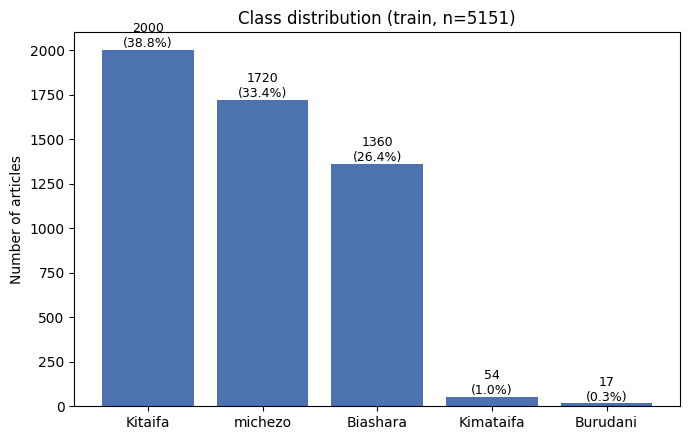

In [3]:
counts = train['category'].value_counts()
props = train['category'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': counts, 'percent': props.round(2)})
print(summary)

order = counts.index.tolist()
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(order, [counts[c] for c in order], color='#4C72B0')
ax.set_ylabel("Number of articles")
ax.set_title(f"Class distribution (train, n={len(train)})")
for b, c in zip(bars, [counts[o] for o in order]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, f"{c}\n({100*c/len(train):.1f}%)", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150)
plt.show()

**Finding:** the classes are severely imbalanced. `Kitaifa` (national, 38.8%),
`michezo` (sports, 33.4%) and `Biashara` (business, 26.4%) together account for ~99% of
the data, while `Kimataifa` (international) has only 54 examples (1.0%) and `Burudani`
(entertainment) only 17 (0.3%). This has direct modelling implications:
- **Macro-F1** (not accuracy, and not micro-F1) is the appropriate evaluation metric, since
  accuracy would be dominated by the three majority classes.
- The two minority classes are too small for a conventional train/val/test split to leave
  enough validation examples — stratified k-fold, class-weighted loss, or oversampling
  (e.g. back-translation augmentation) should be considered.
- Any model comparison must report per-class F1, not just an aggregate score, or the
  near-absence of `Burudani`/`Kimataifa` signal will be invisible.

## 3. Document length
Sequence length drives architecture choices directly: it sets the truncation/padding length
for RNN/Transformer models and affects whether long-range dependencies actually matter for
this task.

In [4]:
train['n_words'] = train['content'].astype(str).str.split().apply(len)
train['n_chars'] = train['content'].astype(str).str.len()

print(train['n_words'].describe())
print()
print("Percentiles:")
print(train['n_words'].quantile([0.01,0.05,0.5,0.90,0.95,0.99]))

count    5151.000000
mean      314.786838
std       193.687881
min         0.000000
25%       199.000000
50%       271.000000
75%       369.000000
max      2564.000000
Name: n_words, dtype: float64

Percentiles:
0.01      85.5
0.05     123.5
0.50     271.0
0.90     506.0
0.95     680.0
0.99    1087.5
Name: n_words, dtype: float64


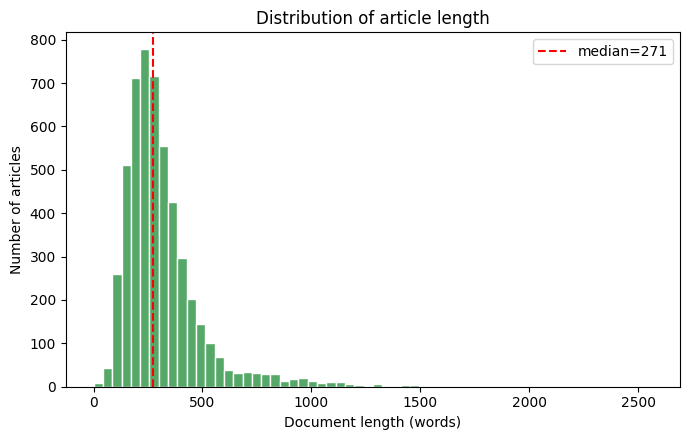

In [5]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(train['n_words'], bins=60, color='#55A868', edgecolor='white')
ax.axvline(train['n_words'].median(), color='red', linestyle='--', label=f"median={int(train['n_words'].median())}")
ax.set_xlabel("Document length (words)")
ax.set_ylabel("Number of articles")
ax.set_title("Distribution of article length")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_length_hist.png", dpi=150)
plt.show()

category
Kitaifa      322.0
michezo      254.0
Biashara     233.0
Kimataifa    132.0
Burudani      63.0
Name: n_words, dtype: float64


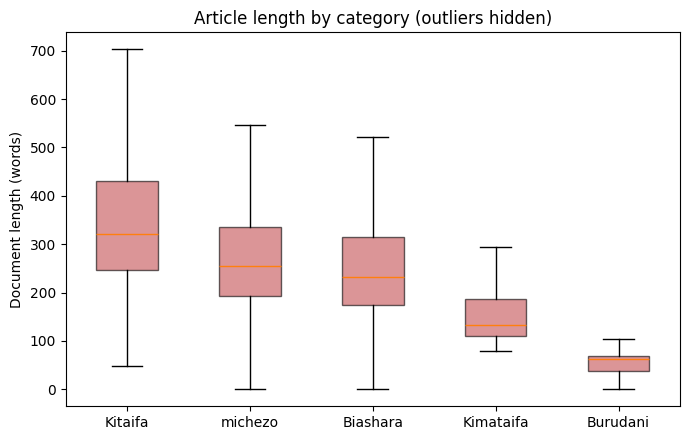

In [6]:
print(train.groupby('category')['n_words'].median().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7,4.5))
data_by_cat = [train[train.category==c]['n_words'].values for c in order]
bp = ax.boxplot(data_by_cat, tick_labels=order, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#C44E52'); patch.set_alpha(0.6)
ax.set_ylabel("Document length (words)")
ax.set_title("Article length by category (outliers hidden)")
plt.tight_layout()
plt.savefig("fig3_length_by_category.png", dpi=150)
plt.show()

**Finding:** articles range from a handful of words to 2,564 words (median 271, 95th
percentile ≈ 680). Length also varies systematically by category — `Kitaifa` articles run
long (median ≈ 322 words) while `Burudani` articles are much shorter (median ≈ 63 words).
Since length correlates with the label, a model that only sees a truncated prefix of long
articles risks losing information disproportionately for some classes. A max sequence length
around 400–500 tokens covers roughly the 90th percentile while keeping training tractable;
this should be validated against whichever tokeniser (word-level vs. subword) is finally used.

## 4. Data quality: malformed records
A blind pass over the raw text surfaces a data-quality issue that isn't obvious from
summary statistics alone.

In [7]:
list_artifact = train['content'].str.contains(r"^\s*\[.*\]\s*$", regex=True)
print("Rows that are stringified Python list literals:", list_artifact.sum())
print(train[list_artifact]['category'].value_counts())
print()
print(repr(train.loc[list_artifact, 'content'].iloc[0][:300]))

Rows that are stringified Python list literals: 255
category
michezo    255
Name: count, dtype: int64

"['Mshambuliaji wa Real Madrid Gareth Bale anakaribia kuondoka katika klabu hiyo kulingana na mkufunzi wa klabu hiyo Zinedine Zidane. ', 'Mchezaji huyo wa taifa la Wales aliwachwa nje wakati Real Madrid ilipolazwa 3-1 na Bayern Munich nchini Marekani.', 'Akizungumza baada ya mechi hiyo, Zidane alisem"


**Finding:** 255 of the 1,720 `michezo` (sports) articles (~14.8% of that class) are not
plain text — they are Python list literals (e.g. `['para 1...', 'para 2...', ...]`), almost
certainly an artefact of how multi-paragraph sports round-up articles were scraped and
serialised. They still contain genuine Swahili content, but with literal `[`, `]`, `'`, and
escaped-quote characters mixed in, and they concatenate what are effectively several
short bulletins (transfer-news digests) into one very long "article." This: (a) explains
part of the heavy right skew in `michezo` document length seen above, and (b) needs explicit
cleaning (strip list/quote syntax and re-join, or `ast.literal_eval` + join) before
tokenisation — otherwise a word-level model will burn vocabulary slots on tokens like
`['mshambuliaji` and `psg',`.

Two further checks below: near-empty documents and near-duplicate content, both of which
should be handled (drop or flag) before training.

In [8]:
print("Documents with 0 words:", (train['n_words']==0).sum())
print("Documents with <10 words:", (train['n_words']<10).sum())
print(train[train['n_words']<3][['id','category','content']])

Documents with 0 words: 1
Documents with <10 words: 3
          id  category content
2861  SW4225  Burudani       .
4906   SW724   michezo   ['.']
5006   SW832  Biashara        


## 5. Vocabulary and morphology
Swahili is a Bantu language with rich noun-class and verb morphology (agglutinative-like
prefixing/suffixing), which tends to inflate word-level vocabulary size relative to
English for a similarly sized corpus. This has a direct bearing on tokenisation choice.

In [9]:
def tokenize(text):
    return re.findall(r"[A-Za-zÀ-ÿ']+", str(text).lower())

all_tokens = []
for t in train['content']:
    all_tokens.extend(tokenize(t))

vocab = Counter(all_tokens)
hapax = sum(1 for w,c in vocab.items() if c == 1)

print("Total tokens:", len(all_tokens))
print("Vocabulary size (unique word-level tokens):", len(vocab))
print(f"Hapax legomena (appear once): {hapax} ({100*hapax/len(vocab):.1f}% of vocabulary)")
print()
print("Top 15 tokens overall (function words dominate, as expected):")
for w,c in vocab.most_common(15):
    print(f"  {w}: {c}")

Total tokens: 1628762
Vocabulary size (unique word-level tokens): 74006
Hapax legomena (appear once): 39604 (53.5% of vocabulary)

Top 15 tokens overall (function words dominate, as expected):
  ya: 87119
  na: 82488
  wa: 66559
  kwa: 39414
  katika: 21290
  za: 18678
  alisema: 18233
  ni: 15556
  la: 14776
  hiyo: 12514
  kuwa: 12366
  cha: 8792
  kwenye: 7699
  mwaka: 6745
  huo: 6464


**Finding:** More than 74,000 unique word-level tokens, ~1.63M tokens, and 53.5% of the tokens are unique.
vocabulary occurring only once. This is a high rate of rare words and a lot of it can be accounted for by plausibility,
noun-class prefixes/verb conjugations (morphological variation) of the same root Not real word difference but rather word difference in a way of thinking. Subword is direct motivation for this. The tokeniser is a process that breaks down text into a sequence of tokens (tensors).The tokeniser is a process that splits text into tokens (tensors), such as what pretrained models like would do: tokeniser** (BPE / SentencePiece / WordPiece). Also, if you have a word-level vocabulary, you can use multilingual BERT/XLM-R or AfriBERTa. Allow the model to be statistically strong for all morphological forms of a same root.
and keep the out-of-vocabulary rate low at inference time.

## 6. Category separability (sanity check)
A quick lexical check — after removing very common function words, do the categories show
distinct, topically coherent vocabulary? This isn't a model, just evidence that the sequential
signal in the text is genuinely informative for classification.

In [10]:
sw_stop = set('''
ya na wa kwa katika za alisema ni la hiyo kuwa cha kwenye mwaka huo serikali
ili baada tanzania pia vya nchi nchini kutoka kama hilo hivyo wakati hayo
akisema aliongeza yake wake zake lake yao wao huyo hao hii huu hivi mmoja
watu mtu bwana bi wote wale kuhusu vile kutokana ambapo ambaye lakini au
kila si tu hata je bado kabla mno sana zaidi pale hapo huko
'''.split())

def clean_tokens(text):
    toks = re.findall(r"[A-Za-zÀ-ÿ']+", str(text).lower())
    return [t for t in toks if t not in sw_stop and len(t) > 2]

for cat in order:
    sub = train[train.category==cat]['content']
    toks = []
    for t in sub:
        toks.extend(clean_tokens(t))
    top = Counter(toks).most_common(10)
    print(f"--- {cat} (n={len(sub)}) ---")
    print(", ".join(f"{w}({c})" for w,c in top))
    print()

--- Kitaifa (n=2000) ---
mkuu(2267), rais(2237), kazi(2124), waziri(1990), wananchi(1929), fedha(1895), pamoja(1821), sasa(1715), mbalimbali(1665), hizo(1565)

--- michezo (n=1720) ---
timu(4298), mchezo(3490), simba(2374), ligi(2283), mechi(2042), yanga(1992), wachezaji(1974), klabu(1955), dhidi(1779), nafasi(1777)



--- Biashara (n=1360) ---
biashara(1434), huduma(1350), amesema(1263), kampuni(1158), viwanda(1101), sasa(1050), fedha(1035), benki(1014), mkuu(992), pamoja(972)

--- Kimataifa (n=54) ---
rais(57), amesema(34), marekani(34), kwamba(29), kenya(28), kampuni(28), china(27), siku(26), afrika(22), uingereza(21)

--- Burudani (n=17) ---
amesema(9), nafasi(7), brown(7), marekani(6), nigeria(6), taifa(6), kupitia(6), sasa(6), baadhi(5), duniani(4)



**Finding:** the top words per category are topically coherent and clearly separable even
under a simple bag-of-words view — e.g. `michezo` surfaces `timu, mchezo, simba, ligi, mechi,
yanga, wachezaji, klabu` (team, match, league, players, club, and the two dominant Tanzanian
football clubs Simba SC and Yanga SC); `Biashara` surfaces `biashara, kampuni, viwanda, benki`
(business, company, industry, bank). This is a useful sanity check but not the whole story:
it also means a simple keyword/TF-IDF baseline should perform respectably, which is exactly why
the assignment calls for comparing sequential neural approaches against non-sequential
baselines — the comparison should reveal whether modelling word *order* and *context* (not
just presence of key terms) adds real value on top of this lexical signal.

Also visible: English proper nouns for foreign clubs/players (`Manchester`, `PSG`, `Barcelona`)
appear inside otherwise-Swahili sentences in `michezo`. A common-English-stopword check found
this is negligible in aggregate (well under 1% of tokens are common English words), so
code-switching is not a first-order concern for this dataset — but named-entity noise
(non-Swahili proper nouns) is still a source of out-of-vocabulary tokens worth accounting
for in preprocessing.

## 7. Summary of findings and modelling implications

| Finding | Implication for sequential modelling |
|---|---|
| Severe class imbalance (2 classes <2% of data) | Use macro-F1 as primary metric; stratified splitting; class-weighted loss or augmentation for `Kimataifa`/`Burudani` |
| Long, right-skewed documents (median 271, up to 2,564 words); length varies by category | Truncate/pad to ~400–500 tokens (covers ~90th pct); be aware truncation may disproportionately affect long-form categories like `Kitaifa` |
| 255 `michezo` records are malformed Python-list-literal strings | Requires a preprocessing step to detect and clean these before tokenisation |
| High morphological richness (53.5% hapax legomena in 74k-word vocabulary) | Favour subword tokenisation (BPE/SentencePiece) over word-level vocabularies to control OOV rate |
| Categories are lexically well-separated even under simple frequency counts | Non-sequential baselines (e.g. TF-IDF + linear classifier) are a meaningful comparison point for judging whether sequential architectures add value |
| Negligible code-switching, but foreign proper nouns present in `michezo` | Named-entity tokens are a minor but real OOV source; not severe enough to need special code-switching handling |
| Different ID schemes between train (`SW#`) and test (long hash) | No leakage risk from ID matching; submission files must key on `swahili_id` |
